<a href="https://colab.research.google.com/github/dennisorji/intelligent-microscopy-materials/blob/main/04_transfer_learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Intelligent Microscopy for Materials

## Notebook 04 — Transfer Learning for SEM Morphology Classification

### Objective

This notebook evaluates whether transfer learning from a pretrained convolutional neural network can improve SEM morphology classification compared with:

- the classical handcrafted-feature baseline, and
- the convolutional neural network trained from scratch.

A pretrained ResNet-18 model will be adapted to the SEM dataset while preserving the fixed train/validation/test split established during the dataset audit.

Model development and selection will use only the training and validation sets. The held-out test set will remain untouched until the final transfer-learning model has been selected and frozen.

### Fixed benchmark results

| Model | Test Accuracy | Balanced Accuracy | Macro-F1 |
|---|---:|---:|---:|
| HistGradientBoosting | 0.7789 | 0.6713 | 0.6800 |
| CNN from scratch | 0.7947 | 0.8421 | 0.7425 |

The transfer-learning model will be compared against these fixed benchmarks using the same test set.

In [ ]:
# ============================================================
# 1. Environment setup and reproducibility
# ============================================================

from pathlib import Path
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import models, transforms

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
print("Device:", DEVICE)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

PyTorch version: 2.11.0+cu128
CUDA available: True
Device: cuda
GPU: Tesla T4


## 2. Mount Google Drive and Load the Fixed Dataset Split

The train, validation, and test assignments created during the dataset audit are reused without modification.

This ensures that all model families are evaluated on exactly the same samples and prevents information leakage caused by redefining the split during transfer-learning experiments.

In [ ]:
# ============================================================
# 2. Mount Google Drive
# ============================================================

from google.colab import drive

drive.mount("/content/drive")

PROJECT_ROOT = Path(
    "/content/drive/MyDrive/intelligent-microscopy-materials"
)

PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"

SPLIT_MANIFEST_PATH = PROCESSED_DIR / "sem_split_manifest.csv"

print("Project root:", PROJECT_ROOT)
print("Split manifest exists:", SPLIT_MANIFEST_PATH.exists())

Mounted at /content/drive
Project root: /content/drive/MyDrive/intelligent-microscopy-materials
Split manifest exists: True


In [ ]:
# ============================================================
# 4. Verify classes and split integrity
# ============================================================

print("Number of classes:", split_manifest["class"].nunique())
print()

print("Classes:")
for cls in sorted(split_manifest["class"].unique()):
    print("-", cls)

print()
print("Split counts:")
print(split_manifest["split"].value_counts())

Number of classes: 10

Classes:
- Biological
- Fibres
- Films/Coated Surface
- MEMS Devices/Electrodes
- Nanowires
- Particles
- Patterned Surface
- Porous/Sponge
- Powder
- Tips

Split counts:
split
train         14519
test           3112
validation     3111
Name: count, dtype: int64


## 3. Verify Availability of the Raw SEM Images

The fixed manifest contains the metadata and split assignments, but the neural network must still access the underlying SEM image files.

Because Colab runtime storage is temporary, the raw image directory may need to be reconstructed whenever a new runtime is created. Before downloading anything, the notebook checks whether the dataset is already present.

In [ ]:
# ============================================================
# 5. Check whether the raw SEM dataset is already available
# ============================================================

DATA_ROOT = Path("/content/sem_data")

print("Dataset directory exists:", DATA_ROOT.exists())

if DATA_ROOT.exists():
    image_files = list(DATA_ROOT.rglob("*.jpg"))
    print("JPG images currently available:", len(image_files))
else:
    print("Raw SEM dataset must be restored in this runtime.")

Dataset directory exists: False
Raw SEM dataset must be restored in this runtime.


## 4. Restore the Raw SEM Dataset

The raw SEM images are restored from the original dataset archives into the temporary Colab runtime.

The downloaded archives are deleted immediately after extraction to avoid unnecessary storage use. No preprocessing, deduplication, or resplitting is performed here; the previously frozen manifest remains the authoritative modelling index.

In [ ]:
# ============================================================
# 6. Restore raw SEM dataset
# ============================================================

import tarfile

DATA_ROOT = Path("/content/sem_data")
ARCHIVE_ROOT = Path("/content/sem_archives")

DATA_ROOT.mkdir(parents=True, exist_ok=True)
ARCHIVE_ROOT.mkdir(parents=True, exist_ok=True)

BASE_URL = "https://b2share.eudat.eu/records/zja8y-53j14/files"

DATASET_FILES = {
    "Fibres": "Fibres.tar",
    "Porous_Sponge": "Porous_Sponge.tar",
    "Films_Coated_Surface": "Films_Coated_Surface.tar",
    "Biological": "Biological.tar",
    "Tips": "Tips.tar",
    "Powder": "Powder.tar",
    "Nanowires": "Nanowires.tar",
    "Particles": "Particles.tar",
    "Patterned_surface": "Patterned_surface.tar",
    "MEMS_devices_and_electrodes": "MEMS_devices_and_electrodes.tar",
}

for folder_name, archive_name in DATASET_FILES.items():

    class_dir = DATA_ROOT / folder_name
    archive_path = ARCHIVE_ROOT / archive_name

    # Skip a class if already restored
    if class_dir.exists():
        print(f"Already available: {folder_name}")
        continue

    print(f"\nDownloading {archive_name}...")

    url = f"{BASE_URL}/{archive_name}?download=1"

    !wget -q --show-progress -O "$archive_path" "$url"

    if (
        not archive_path.exists()
        or archive_path.stat().st_size == 0
    ):
        raise RuntimeError(
            f"Download failed for {archive_name}"
        )

    print(f"Extracting {archive_name}...")

    with tarfile.open(archive_path, "r") as tar:
        tar.extractall(DATA_ROOT)

    if not class_dir.exists():
        raise RuntimeError(
            f"Expected folder was not created: {class_dir}"
        )

    # Remove temporary archive
    archive_path.unlink()

    print(f"Restored: {folder_name}")

print("\nDataset restoration complete.")


/content/sem_archiv 100%[===================>]  77.23M  19.3MB/s    in 5.0s    
Extracting Fibres.tar...
Restored: Fibres



/tmp/ipykernel_361/1269057395.py:55: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall(DATA_ROOT)


/content/sem_archiv 100%[===================>] 114.02M  20.7MB/s    in 6.7s    
Extracting Porous_Sponge.tar...
Restored: Porous_Sponge

/content/sem_archiv 100%[===================>] 188.48M  16.7MB/s    in 12s     
Extracting Films_Coated_Surface.tar...
Restored: Films_Coated_Surface

/content/sem_archiv 100%[===================>] 671.22M  14.8MB/s    in 47s     
Extracting Biological.tar...
Restored: Biological

/content/sem_archiv 100%[===================>] 674.57M  19.8MB/s    in 41s     
Extracting Tips.tar...
Restored: Tips

/content/sem_archiv 100%[===================>] 825.71M  15.1MB/s    in 56s     
Extracting Powder.tar...
Restored: Powder

/content/sem_archiv 100%[===================>]   2.05G  6.79MB/s    in 3m 39s  
Extracting Nanowires.tar...
Restored: Nanowires

/content/sem_archiv 100%[===================>]   2.35G  16.1MB/s    in 2m 39s  
Extracting Particles.tar...
Restored: Particles

/content/sem_archiv 100%[===================>]   2.68G  14.6MB/s    in 3m 8s   
E

In [ ]:
# ============================================================
# 7. Attach runtime paths and verify frozen modelling dataset
# ============================================================

split_manifest["runtime_path"] = (
    split_manifest["relative_path"]
    .apply(lambda p: DATA_ROOT / p)
)

split_manifest["file_exists"] = (
    split_manifest["runtime_path"]
    .apply(lambda p: p.exists())
)

print(
    "Frozen modelling images:",
    len(split_manifest)
)

print(
    "Images found:",
    split_manifest["file_exists"].sum()
)

print(
    "Images missing:",
    (~split_manifest["file_exists"]).sum()
)

Frozen modelling images: 20742
Images found: 20742
Images missing: 0


## 5. Transfer-Learning Preprocessing

ResNet-18 was originally pretrained on three-channel ImageNet images, whereas the SEM morphology task is fundamentally grayscale.

To retain the pretrained network architecture while keeping the experiment focused on morphology, each SEM image is:

1. cropped to the upper 78.125% of its height to remove the acquisition metadata strip;
2. converted to grayscale;
3. replicated across three channels to match the pretrained ResNet-18 input interface;
4. resized to 150 × 256 pixels, preserving approximately the original SEM morphology aspect ratio;
5. normalized using the ImageNet normalization statistics expected by the pretrained network.

Only the training set receives augmentation. Horizontal and vertical flips are used because SEM morphology does not generally have a privileged image orientation. Rotation is excluded because earlier inspection showed that it introduced artificial corner regions.

The validation and test transformations remain deterministic.

In [ ]:
# ============================================================
# 8. Define transfer-learning preprocessing
# ============================================================

from PIL import Image

CROP_FRACTION = 0.78125
IMAGE_SIZE = (150, 256)

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]


def crop_morphology_region(img):
    """
    Retain the upper 78.125% of the image height,
    removing the SEM acquisition metadata strip.
    """
    width, height = img.size
    crop_height = int(round(height * CROP_FRACTION))

    return img.crop(
        (0, 0, width, crop_height)
    )


train_transform = transforms.Compose([
    transforms.Lambda(crop_morphology_region),

    # Remove colour information but produce the 3 channels
    # required by pretrained ResNet-18.
    transforms.Grayscale(num_output_channels=3),

    transforms.Resize(IMAGE_SIZE),

    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.5),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=IMAGENET_MEAN,
        std=IMAGENET_STD
    ),
])


eval_transform = transforms.Compose([
    transforms.Lambda(crop_morphology_region),
    transforms.Grayscale(num_output_channels=3),
    transforms.Resize(IMAGE_SIZE),
    transforms.ToTensor(),

    transforms.Normalize(
        mean=IMAGENET_MEAN,
        std=IMAGENET_STD
    ),
])

print("Training transform:")
print(train_transform)

print("\nValidation/test transform:")
print(eval_transform)

Training transform:
Compose(
    Lambda()
    Grayscale(num_output_channels=3)
    Resize(size=(150, 256), interpolation=bilinear, max_size=None, antialias=True)
    RandomHorizontalFlip(p=0.5)
    RandomVerticalFlip(p=0.5)
    ToTensor()
    Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
)

Validation/test transform:
Compose(
    Lambda()
    Grayscale(num_output_channels=3)
    Resize(size=(150, 256), interpolation=bilinear, max_size=None, antialias=True)
    ToTensor()
    Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
)


In [ ]:
# ============================================================
# 9. Prepare fixed dataframes and class mapping
# ============================================================

train_df = (
    split_manifest[
        split_manifest["split"] == "train"
    ]
    .copy()
    .reset_index()
    .rename(columns={"index": "manifest_index"})
)

val_df = (
    split_manifest[
        split_manifest["split"] == "validation"
    ]
    .copy()
    .reset_index()
    .rename(columns={"index": "manifest_index"})
)

test_df = (
    split_manifest[
        split_manifest["split"] == "test"
    ]
    .copy()
    .reset_index()
    .rename(columns={"index": "manifest_index"})
)


classes = sorted(
    split_manifest["class"].unique()
)

class_to_idx = {
    class_name: idx
    for idx, class_name in enumerate(classes)
}

idx_to_class = {
    idx: class_name
    for class_name, idx in class_to_idx.items()
}


print("Train:", len(train_df))
print("Validation:", len(val_df))
print("Test:", len(test_df))

print("\nClass mapping:")
for class_name, idx in class_to_idx.items():
    print(f"{idx}: {class_name}")

Train: 14519
Validation: 3111
Test: 3112

Class mapping:
0: Biological
1: Fibres
2: Films/Coated Surface
3: MEMS Devices/Electrodes
4: Nanowires
5: Particles
6: Patterned Surface
7: Porous/Sponge
8: Powder
9: Tips


In [ ]:
# ============================================================
# 10. PyTorch dataset for transfer learning
# ============================================================

class SEMTransferDataset(Dataset):

    def __init__(
        self,
        dataframe,
        transform,
        class_to_idx
    ):
        self.dataframe = dataframe.copy()
        self.transform = transform
        self.class_to_idx = class_to_idx

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):

        row = self.dataframe.iloc[idx]

        image_path = row["runtime_path"]

        with Image.open(image_path) as img:
            img = img.convert("RGB")

            if self.transform is not None:
                img = self.transform(img)

        label = self.class_to_idx[
            row["class"]
        ]

        manifest_index = int(
            row["manifest_index"]
        )

        return (
            img,
            label,
            manifest_index
        )


train_dataset = SEMTransferDataset(
    train_df,
    train_transform,
    class_to_idx
)

val_dataset = SEMTransferDataset(
    val_df,
    eval_transform,
    class_to_idx
)

test_dataset = SEMTransferDataset(
    test_df,
    eval_transform,
    class_to_idx
)


print("Training samples:", len(train_dataset))
print("Validation samples:", len(val_dataset))
print("Test samples:", len(test_dataset))

Training samples: 14519
Validation samples: 3111
Test samples: 3112


In [ ]:
# ============================================================
# 11. Inspect one transformed sample
# ============================================================

sample_image, sample_label, sample_index = train_dataset[0]

print("Tensor shape:", sample_image.shape)
print("Tensor dtype:", sample_image.dtype)
print("Class index:", sample_label)
print("Class name:", idx_to_class[sample_label])
print("Manifest index:", sample_index)
print("Finite values:", torch.isfinite(sample_image).all().item())
print(
    "Tensor range:",
    float(sample_image.min()),
    "to",
    float(sample_image.max())
)

Tensor shape: torch.Size([3, 150, 256])
Tensor dtype: torch.float32
Class index: 1
Class name: Fibres
Manifest index: 3
Finite values: True
Tensor range: -1.7240346670150757 to 2.0996952056884766


## 6. Data Loading and Visual Preprocessing Check

PyTorch DataLoaders are created for the fixed training, validation, and test partitions.

The training loader shuffles samples, whereas the validation and test loaders remain deterministic. Before model construction, a small training batch is visually inspected after reversing normalization to confirm that morphology is preserved and no unintended preprocessing artifacts have been introduced.

In [ ]:
# ============================================================
# 12. Create DataLoaders
# ============================================================

BATCH_SIZE = 64
NUM_WORKERS = 2

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=True,
    persistent_workers=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True,
    persistent_workers=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True,
    persistent_workers=True
)

print("Training batches:", len(train_loader))
print("Validation batches:", len(val_loader))
print("Test batches:", len(test_loader))

Training batches: 227
Validation batches: 49
Test batches: 49


Batch image shape: torch.Size([64, 3, 150, 256])
Batch label shape: torch.Size([64])


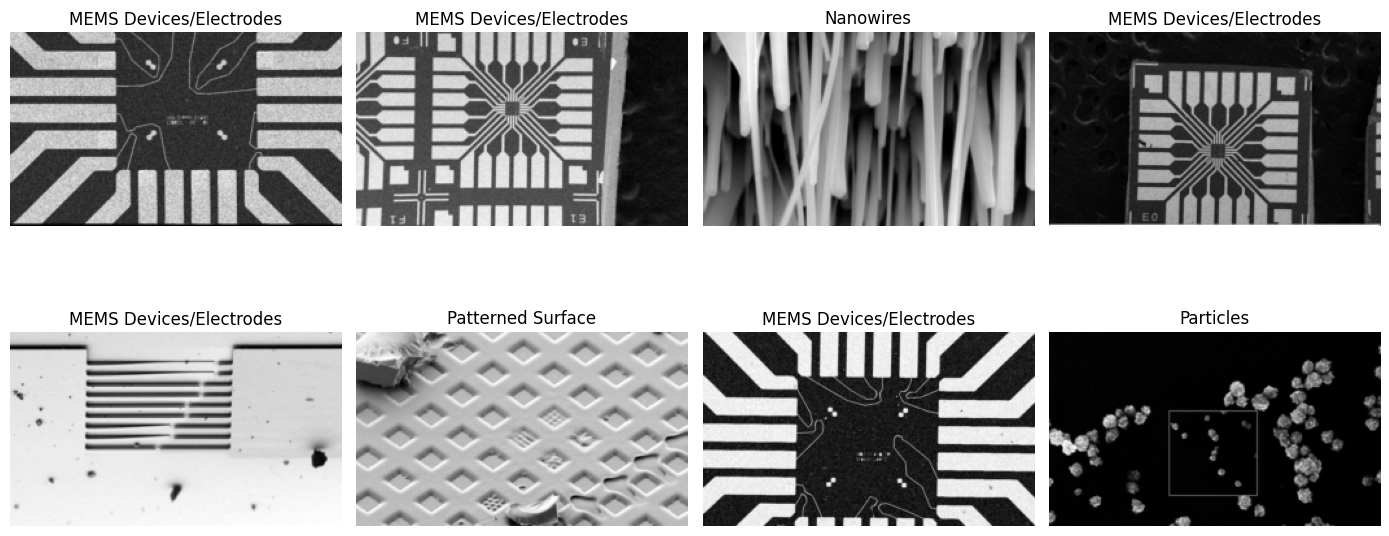

In [ ]:
# ============================================================
# 13. Visually inspect one training batch
# ============================================================

images, labels, manifest_indices = next(iter(train_loader))

print("Batch image shape:", images.shape)
print("Batch label shape:", labels.shape)

mean = torch.tensor(IMAGENET_MEAN).view(3, 1, 1)
std = torch.tensor(IMAGENET_STD).view(3, 1, 1)

fig, axes = plt.subplots(2, 4, figsize=(14, 7))

for i, ax in enumerate(axes.flat):

    # Reverse ImageNet normalization for display
    image = images[i].cpu() * std + mean

    image = image.clamp(0, 1)

    # Channels are replicated grayscale channels,
    # so displaying one channel is sufficient.
    image = image[0].numpy()

    ax.imshow(image, cmap="gray")
    ax.set_title(idx_to_class[int(labels[i])])
    ax.axis("off")

plt.tight_layout()
plt.show()

## 7. Pretrained ResNet-18 Model

A ResNet-18 pretrained on ImageNet is used as the transfer-learning backbone.

For the first training stage, all pretrained convolutional layers are frozen and only the final classification layer is replaced and trained for the ten SEM morphology classes.

This provides a controlled initial transfer-learning stage in which the pretrained visual representation is retained while a task-specific classifier is learned.

The held-out test set remains unused.

In [ ]:
# ============================================================
# 14. Load pretrained ResNet-18
# ============================================================

weights = models.ResNet18_Weights.DEFAULT

model = models.resnet18(
    weights=weights
)

# Freeze the pretrained backbone
for parameter in model.parameters():
    parameter.requires_grad = False

# Replace ImageNet's 1000-class classifier
# with our 10-class SEM classifier
num_features = model.fc.in_features

model.fc = nn.Linear(
    num_features,
    len(classes)
)

model = model.to(DEVICE)

print(model.fc)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 81.8MB/s]


Linear(in_features=512, out_features=10, bias=True)


In [ ]:
# ============================================================
# 15. Inspect model parameter counts
# ============================================================

total_parameters = sum(
    p.numel() for p in model.parameters()
)

trainable_parameters = sum(
    p.numel()
    for p in model.parameters()
    if p.requires_grad
)

print(f"Total parameters: {total_parameters:,}")
print(f"Trainable parameters: {trainable_parameters:,}")
print(
    f"Frozen parameters: "
    f"{total_parameters - trainable_parameters:,}"
)

Total parameters: 11,181,642
Trainable parameters: 5,130
Frozen parameters: 11,176,512


### Class-Weighted Training Objective

The dataset remains strongly imbalanced, with substantially fewer examples in classes such as Fibres and Porous/Sponge than in the dominant classes.

Balanced class weights are therefore calculated from the training partition only and incorporated into the cross-entropy loss. No validation or test labels contribute to weight estimation.

In [ ]:
# ============================================================
# 16. Compute training-only class weights
# ============================================================

train_class_counts = (
    train_df["class"]
    .value_counts()
    .reindex(classes)
)

n_train = len(train_df)
n_classes = len(classes)

class_weights = (
    n_train
    / (n_classes * train_class_counts.values)
)

class_weights_tensor = torch.tensor(
    class_weights,
    dtype=torch.float32,
    device=DEVICE
)

class_weight_table = pd.DataFrame({
    "class": classes,
    "train_count": train_class_counts.values,
    "class_weight": class_weights
})

display(class_weight_table)

,class,train_count,class_weight
0,Biological,670,2.167015
1,Fibres,105,13.827619
2,Films/Coated Surface,211,6.881043
3,MEMS Devices/Electrodes,3195,0.454429
4,Nanowires,2610,0.556284
5,Particles,2667,0.544394
6,Patterned Surface,3249,0.446876
7,Porous/Sponge,119,12.200840
8,Powder,596,2.436074
9,Tips,1097,1.323519


In [ ]:
# ============================================================
# 17. Forward-pass sanity check
# ============================================================

model.eval()

with torch.no_grad():

    test_batch = images[:8].to(
        DEVICE,
        non_blocking=True
    )

    logits = model(test_batch)

print("Input shape:", test_batch.shape)
print("Output shape:", logits.shape)
print(
    "Finite outputs:",
    torch.isfinite(logits).all().item()
)

Input shape: torch.Size([8, 3, 150, 256])
Output shape: torch.Size([8, 10])
Finite outputs: True


## 8. Stage 1 — Train the New Classification Head

Transfer learning begins by freezing the pretrained ResNet-18 feature extractor and training only the newly initialized ten-class classification layer.

The pretrained BatchNorm statistics are also held fixed during this stage so that the backbone remains a genuinely frozen representation.

Class-weighted cross-entropy is used to address the strong class imbalance. Model selection is based exclusively on validation macro-F1.

Mixed-precision training is used on the GPU to reduce computation time and memory use. The best validation checkpoint is written to Google Drive so that progress survives a runtime interruption.

The test set remains untouched.

In [ ]:
# ============================================================
# 18. Persistent transfer-learning directories
# ============================================================

MODEL_DIR = (
    PROJECT_ROOT
    / "models"
    / "transfer_learning"
)

RESULTS_DIR = (
    PROJECT_ROOT
    / "results"
    / "transfer_learning"
)

MODEL_DIR.mkdir(
    parents=True,
    exist_ok=True
)

RESULTS_DIR.mkdir(
    parents=True,
    exist_ok=True
)

STAGE1_BEST_PATH = (
    MODEL_DIR
    / "best_resnet18_stage1.pt"
)

STAGE1_LAST_PATH = (
    MODEL_DIR
    / "last_resnet18_stage1.pt"
)

STAGE1_HISTORY_PATH = (
    RESULTS_DIR
    / "stage1_training_history.csv"
)

print("Model directory:", MODEL_DIR)
print("Results directory:", RESULTS_DIR)

Model directory: /content/drive/MyDrive/intelligent-microscopy-materials/models/transfer_learning
Results directory: /content/drive/MyDrive/intelligent-microscopy-materials/results/transfer_learning


In [ ]:
# ============================================================
# 19. Stage 1 objective and optimizer
# ============================================================

criterion = nn.CrossEntropyLoss(
    weight=class_weights_tensor
)

optimizer = torch.optim.AdamW(
    model.fc.parameters(),
    lr=1e-3,
    weight_decay=1e-4
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="max",
    factor=0.5,
    patience=1,
    min_lr=1e-6
)

scaler = torch.amp.GradScaler(
    "cuda",
    enabled=torch.cuda.is_available()
)

print("Stage 1 optimizer configured.")
print(
    "Trainable parameters:",
    sum(
        p.numel()
        for p in model.parameters()
        if p.requires_grad
    )
)

Stage 1 optimizer configured.
Trainable parameters: 5130


In [ ]:
# ============================================================
# 20. Training and validation utilities
# ============================================================

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score
)


def set_stage1_train_mode(model):
    """
    Train the new classifier while keeping the frozen
    pretrained BatchNorm statistics fixed.
    """
    model.train()

    for module in model.modules():
        if isinstance(module, nn.BatchNorm2d):
            module.eval()


def train_one_epoch(
    model,
    loader,
    criterion,
    optimizer,
    scaler,
    device
):

    set_stage1_train_mode(model)

    running_loss = 0.0
    all_targets = []
    all_predictions = []

    for batch_images, batch_labels, _ in loader:

        batch_images = batch_images.to(
            device,
            non_blocking=True
        )

        batch_labels = batch_labels.to(
            device,
            non_blocking=True
        )

        optimizer.zero_grad(
            set_to_none=True
        )

        with torch.amp.autocast(
            device_type="cuda",
            enabled=torch.cuda.is_available()
        ):

            logits = model(batch_images)

            loss = criterion(
                logits,
                batch_labels
            )

        scaler.scale(loss).backward()

        scaler.step(optimizer)
        scaler.update()

        running_loss += (
            loss.item()
            * batch_images.size(0)
        )

        predictions = logits.argmax(dim=1)

        all_targets.extend(
            batch_labels.detach().cpu().numpy()
        )

        all_predictions.extend(
            predictions.detach().cpu().numpy()
        )

    epoch_loss = (
        running_loss
        / len(loader.dataset)
    )

    accuracy = accuracy_score(
        all_targets,
        all_predictions
    )

    balanced_accuracy = balanced_accuracy_score(
        all_targets,
        all_predictions
    )

    macro_f1 = f1_score(
        all_targets,
        all_predictions,
        average="macro"
    )

    return {
        "loss": epoch_loss,
        "accuracy": accuracy,
        "balanced_accuracy": balanced_accuracy,
        "macro_f1": macro_f1
    }


@torch.no_grad()
def evaluate_model(
    model,
    loader,
    criterion,
    device
):

    model.eval()

    running_loss = 0.0
    all_targets = []
    all_predictions = []

    for batch_images, batch_labels, _ in loader:

        batch_images = batch_images.to(
            device,
            non_blocking=True
        )

        batch_labels = batch_labels.to(
            device,
            non_blocking=True
        )

        with torch.amp.autocast(
            device_type="cuda",
            enabled=torch.cuda.is_available()
        ):

            logits = model(batch_images)

            loss = criterion(
                logits,
                batch_labels
            )

        running_loss += (
            loss.item()
            * batch_images.size(0)
        )

        predictions = logits.argmax(dim=1)

        all_targets.extend(
            batch_labels.cpu().numpy()
        )

        all_predictions.extend(
            predictions.cpu().numpy()
        )

    epoch_loss = (
        running_loss
        / len(loader.dataset)
    )

    accuracy = accuracy_score(
        all_targets,
        all_predictions
    )

    balanced_accuracy = balanced_accuracy_score(
        all_targets,
        all_predictions
    )

    macro_f1 = f1_score(
        all_targets,
        all_predictions,
        average="macro"
    )

    return {
        "loss": epoch_loss,
        "accuracy": accuracy,
        "balanced_accuracy": balanced_accuracy,
        "macro_f1": macro_f1
    }

In [ ]:
# ============================================================
# 21. Stage 1 training
# ============================================================

STAGE1_MAX_EPOCHS = 10
STAGE1_PATIENCE = 3

best_val_f1 = -np.inf
epochs_without_improvement = 0

stage1_history = []

for epoch in range(
    1,
    STAGE1_MAX_EPOCHS + 1
):

    train_metrics = train_one_epoch(
        model,
        train_loader,
        criterion,
        optimizer,
        scaler,
        DEVICE
    )

    val_metrics = evaluate_model(
        model,
        val_loader,
        criterion,
        DEVICE
    )

    scheduler.step(
        val_metrics["macro_f1"]
    )

    current_lr = (
        optimizer.param_groups[0]["lr"]
    )

    row = {
        "epoch": epoch,

        "train_loss":
            train_metrics["loss"],

        "train_accuracy":
            train_metrics["accuracy"],

        "train_balanced_accuracy":
            train_metrics["balanced_accuracy"],

        "train_macro_f1":
            train_metrics["macro_f1"],

        "val_loss":
            val_metrics["loss"],

        "val_accuracy":
            val_metrics["accuracy"],

        "val_balanced_accuracy":
            val_metrics["balanced_accuracy"],

        "val_macro_f1":
            val_metrics["macro_f1"],

        "learning_rate": current_lr
    }

    stage1_history.append(row)

    pd.DataFrame(
        stage1_history
    ).to_csv(
        STAGE1_HISTORY_PATH,
        index=False
    )

    checkpoint = {
        "epoch": epoch,
        "model_state_dict":
            model.state_dict(),

        "optimizer_state_dict":
            optimizer.state_dict(),

        "scheduler_state_dict":
            scheduler.state_dict(),

        "val_macro_f1":
            val_metrics["macro_f1"],

        "class_to_idx":
            class_to_idx
    }

    torch.save(
        checkpoint,
        STAGE1_LAST_PATH
    )

    if (
        val_metrics["macro_f1"]
        > best_val_f1
    ):

        best_val_f1 = (
            val_metrics["macro_f1"]
        )

        epochs_without_improvement = 0

        torch.save(
            checkpoint,
            STAGE1_BEST_PATH
        )

        marker = " <-- BEST"

    else:

        epochs_without_improvement += 1
        marker = ""

    print(
        f"Epoch {epoch:02d} | "
        f"Train loss "
        f"{train_metrics['loss']:.4f} | "
        f"Train F1 "
        f"{train_metrics['macro_f1']:.4f} | "
        f"Val acc "
        f"{val_metrics['accuracy']:.4f} | "
        f"Val balanced "
        f"{val_metrics['balanced_accuracy']:.4f} | "
        f"Val F1 "
        f"{val_metrics['macro_f1']:.4f} | "
        f"LR {current_lr:.2e}"
        f"{marker}"
    )

    if (
        epochs_without_improvement
        >= STAGE1_PATIENCE
    ):

        print(
            "\nStage 1 early stopping triggered."
        )
        break


print(
    "\nBest Stage 1 validation macro-F1:",
    round(best_val_f1, 4)
)

Epoch 01 | Train loss 0.9802 | Train F1 0.6088 | Val acc 0.7933 | Val balanced 0.8157 | Val F1 0.6928 | LR 1.00e-03 <-- BEST
Epoch 02 | Train loss 0.5358 | Train F1 0.7383 | Val acc 0.8107 | Val balanced 0.8257 | Val F1 0.7282 | LR 1.00e-03 <-- BEST
Epoch 03 | Train loss 0.4532 | Train F1 0.7677 | Val acc 0.8251 | Val balanced 0.8452 | Val F1 0.7406 | LR 1.00e-03 <-- BEST
Epoch 04 | Train loss 0.4173 | Train F1 0.7813 | Val acc 0.8293 | Val balanced 0.8457 | Val F1 0.7584 | LR 1.00e-03 <-- BEST
Epoch 05 | Train loss 0.3852 | Train F1 0.7925 | Val acc 0.8441 | Val balanced 0.8517 | Val F1 0.7790 | LR 1.00e-03 <-- BEST
Epoch 06 | Train loss 0.3638 | Train F1 0.8019 | Val acc 0.8383 | Val balanced 0.8520 | Val F1 0.7525 | LR 1.00e-03
Epoch 07 | Train loss 0.3391 | Train F1 0.8107 | Val acc 0.8473 | Val balanced 0.8666 | Val F1 0.7745 | LR 5.00e-04
Epoch 08 | Train loss 0.3240 | Train F1 0.8230 | Val acc 0.8534 | Val balanced 0.8655 | Val F1 0.7986 | LR 5.00e-04 <-- BEST
Epoch 09 | Train l

## 9. Stage 1 Performance Review

The frozen-backbone transfer-learning stage produced strong validation performance, indicating that ImageNet-pretrained visual features transfer effectively to SEM morphology classification despite the substantial domain difference.

The best Stage 1 checkpoint is identified using validation macro-F1. This checkpoint, rather than the final training epoch, provides the starting point for controlled fine-tuning.

The held-out test set remains untouched.

In [ ]:
# ============================================================
# 22. Inspect best Stage 1 epoch
# ============================================================

stage1_history_df = pd.read_csv(
    STAGE1_HISTORY_PATH
)

best_stage1_row = (
    stage1_history_df
    .loc[
        stage1_history_df["val_macro_f1"].idxmax()
    ]
)

display(
    best_stage1_row.to_frame(
        name="value"
    )
)

print(
    "\nBest Stage 1 epoch:",
    int(best_stage1_row["epoch"])
)

,value
epoch,9.000000
train_loss,0.315623
train_accuracy,0.871134
train_balanced_accuracy,0.906590
train_macro_f1,0.821654
val_loss,0.433978
val_accuracy,0.857923
val_balanced_accuracy,0.867049
val_macro_f1,0.804453
learning_rate,0.000500



Best Stage 1 epoch: 9


## 10. Stage 2 — Fine-Tune the Highest-Level ResNet Features

Stage 2 begins from the best Stage 1 checkpoint rather than the final epoch.

The final ResNet residual block (`layer4`) and the classification head are made trainable, while the earlier convolutional layers remain frozen.

This provides limited domain adaptation to SEM morphology while reducing the risk of catastrophic forgetting of useful pretrained features.

A substantially lower learning rate is used for the pretrained `layer4` parameters than for the classification head.

Model selection continues to use validation macro-F1 only. The held-out test set remains untouched.

In [ ]:
# ============================================================
# 23. Restore best Stage 1 checkpoint
# ============================================================

stage1_checkpoint = torch.load(
    STAGE1_BEST_PATH,
    map_location=DEVICE,
    weights_only=False
)

model.load_state_dict(
    stage1_checkpoint["model_state_dict"]
)

print(
    "Restored Stage 1 epoch:",
    stage1_checkpoint["epoch"]
)

print(
    "Stage 1 validation macro-F1:",
    stage1_checkpoint["val_macro_f1"]
)

Restored Stage 1 epoch: 9
Stage 1 validation macro-F1: 0.8044528365122163


In [ ]:
# ============================================================
# 24. Configure Stage 2 trainable layers
# ============================================================

# Freeze everything first
for parameter in model.parameters():
    parameter.requires_grad = False

# Unfreeze highest-level residual block
for parameter in model.layer4.parameters():
    parameter.requires_grad = True

# Keep classifier trainable
for parameter in model.fc.parameters():
    parameter.requires_grad = True


total_parameters = sum(
    p.numel()
    for p in model.parameters()
)

trainable_parameters = sum(
    p.numel()
    for p in model.parameters()
    if p.requires_grad
)

print(
    f"Total parameters: {total_parameters:,}"
)

print(
    f"Stage 2 trainable parameters: "
    f"{trainable_parameters:,}"
)

print(
    f"Frozen parameters: "
    f"{total_parameters - trainable_parameters:,}"
)

Total parameters: 11,181,642
Stage 2 trainable parameters: 8,398,858
Frozen parameters: 2,782,784


In [ ]:
# ============================================================
# 25. Stage 2 optimizer and scheduler
# ============================================================

stage2_optimizer = torch.optim.AdamW(
    [
        {
            "params": model.layer4.parameters(),
            "lr": 1e-5
        },
        {
            "params": model.fc.parameters(),
            "lr": 1e-4
        }
    ],
    weight_decay=1e-4
)

stage2_scheduler = (
    torch.optim.lr_scheduler.ReduceLROnPlateau(
        stage2_optimizer,
        mode="max",
        factor=0.5,
        patience=2,
        min_lr=1e-7
    )
)

stage2_scaler = torch.amp.GradScaler(
    "cuda",
    enabled=torch.cuda.is_available()
)

print("Stage 2 optimizer configured.")

print(
    "layer4 learning rate:",
    stage2_optimizer.param_groups[0]["lr"]
)

print(
    "classifier learning rate:",
    stage2_optimizer.param_groups[1]["lr"]
)

Stage 2 optimizer configured.
layer4 learning rate: 1e-05
classifier learning rate: 0.0001


### Stage 2 Training Strategy

During fine-tuning, the trainable `layer4` block is allowed to adapt both its learned weights and its BatchNorm statistics to the SEM domain.

Earlier frozen ResNet blocks remain fixed, including their BatchNorm running statistics. This prevents nominally frozen portions of the network from changing indirectly during training.

Stage 2 begins from the best Stage 1 checkpoint and is evaluated exclusively using the validation set. Its best validation checkpoint will later be compared with the frozen-backbone Stage 1 model before either model is evaluated on the held-out test set.

In [ ]:
# ============================================================
# 26. Stage 2 training-mode control
# ============================================================

def set_stage2_train_mode(model):
    """
    Train layer4 + fc while keeping BatchNorm statistics
    in the earlier frozen backbone fixed.
    """

    model.train()

    for name, module in model.named_modules():

        if isinstance(module, nn.BatchNorm2d):

            # BatchNorm inside layer4 is allowed to adapt.
            if name.startswith("layer4"):
                module.train()

            # Earlier backbone BatchNorm remains frozen.
            else:
                module.eval()

In [ ]:
# ============================================================
# 27. Stage 2 training function
# ============================================================

def train_one_epoch_stage2(
    model,
    loader,
    criterion,
    optimizer,
    scaler,
    device
):

    set_stage2_train_mode(model)

    running_loss = 0.0

    all_targets = []
    all_predictions = []

    for batch_images, batch_labels, _ in loader:

        batch_images = batch_images.to(
            device,
            non_blocking=True
        )

        batch_labels = batch_labels.to(
            device,
            non_blocking=True
        )

        optimizer.zero_grad(
            set_to_none=True
        )

        with torch.amp.autocast(
            device_type="cuda",
            enabled=torch.cuda.is_available()
        ):

            logits = model(batch_images)

            loss = criterion(
                logits,
                batch_labels
            )

        scaler.scale(loss).backward()

        scaler.step(optimizer)
        scaler.update()

        running_loss += (
            loss.item()
            * batch_images.size(0)
        )

        predictions = logits.argmax(dim=1)

        all_targets.extend(
            batch_labels.detach().cpu().numpy()
        )

        all_predictions.extend(
            predictions.detach().cpu().numpy()
        )

    epoch_loss = (
        running_loss
        / len(loader.dataset)
    )

    accuracy = accuracy_score(
        all_targets,
        all_predictions
    )

    balanced_accuracy = balanced_accuracy_score(
        all_targets,
        all_predictions
    )

    macro_f1 = f1_score(
        all_targets,
        all_predictions,
        average="macro"
    )

    return {
        "loss": epoch_loss,
        "accuracy": accuracy,
        "balanced_accuracy": balanced_accuracy,
        "macro_f1": macro_f1
    }

In [ ]:
# ============================================================
# 28. Stage 2 checkpoint paths
# ============================================================

STAGE2_BEST_PATH = (
    MODEL_DIR
    / "best_resnet18_stage2.pt"
)

STAGE2_LAST_PATH = (
    MODEL_DIR
    / "last_resnet18_stage2.pt"
)

STAGE2_HISTORY_PATH = (
    RESULTS_DIR
    / "stage2_training_history.csv"
)

print("Best checkpoint:", STAGE2_BEST_PATH)
print("Last checkpoint:", STAGE2_LAST_PATH)
print("History:", STAGE2_HISTORY_PATH)

Best checkpoint: /content/drive/MyDrive/intelligent-microscopy-materials/models/transfer_learning/best_resnet18_stage2.pt
Last checkpoint: /content/drive/MyDrive/intelligent-microscopy-materials/models/transfer_learning/last_resnet18_stage2.pt
History: /content/drive/MyDrive/intelligent-microscopy-materials/results/transfer_learning/stage2_training_history.csv


In [ ]:
# ============================================================
# 29. Stage 2 fine-tuning
# ============================================================

STAGE2_MAX_EPOCHS = 20
STAGE2_PATIENCE = 5

best_stage2_val_f1 = -np.inf
epochs_without_improvement = 0

stage2_history = []

for epoch in range(
    1,
    STAGE2_MAX_EPOCHS + 1
):

    train_metrics = train_one_epoch_stage2(
        model,
        train_loader,
        criterion,
        stage2_optimizer,
        stage2_scaler,
        DEVICE
    )

    val_metrics = evaluate_model(
        model,
        val_loader,
        criterion,
        DEVICE
    )

    stage2_scheduler.step(
        val_metrics["macro_f1"]
    )

    layer4_lr = (
        stage2_optimizer
        .param_groups[0]["lr"]
    )

    classifier_lr = (
        stage2_optimizer
        .param_groups[1]["lr"]
    )

    row = {
        "epoch": epoch,

        "train_loss":
            train_metrics["loss"],

        "train_accuracy":
            train_metrics["accuracy"],

        "train_balanced_accuracy":
            train_metrics[
                "balanced_accuracy"
            ],

        "train_macro_f1":
            train_metrics["macro_f1"],

        "val_loss":
            val_metrics["loss"],

        "val_accuracy":
            val_metrics["accuracy"],

        "val_balanced_accuracy":
            val_metrics[
                "balanced_accuracy"
            ],

        "val_macro_f1":
            val_metrics["macro_f1"],

        "layer4_lr":
            layer4_lr,

        "classifier_lr":
            classifier_lr
    }

    stage2_history.append(row)

    # Persist history every epoch
    pd.DataFrame(
        stage2_history
    ).to_csv(
        STAGE2_HISTORY_PATH,
        index=False
    )

    checkpoint = {
        "stage": 2,
        "epoch": epoch,

        "model_state_dict":
            model.state_dict(),

        "optimizer_state_dict":
            stage2_optimizer.state_dict(),

        "scheduler_state_dict":
            stage2_scheduler.state_dict(),

        "val_accuracy":
            val_metrics["accuracy"],

        "val_balanced_accuracy":
            val_metrics[
                "balanced_accuracy"
            ],

        "val_macro_f1":
            val_metrics["macro_f1"],

        "class_to_idx":
            class_to_idx
    }

    # Always preserve latest state
    torch.save(
        checkpoint,
        STAGE2_LAST_PATH
    )

    # Preserve best Stage 2 validation model
    if (
        val_metrics["macro_f1"]
        > best_stage2_val_f1
    ):

        best_stage2_val_f1 = (
            val_metrics["macro_f1"]
        )

        epochs_without_improvement = 0

        torch.save(
            checkpoint,
            STAGE2_BEST_PATH
        )

        marker = " <-- BEST"

    else:

        epochs_without_improvement += 1
        marker = ""

    print(
        f"Epoch {epoch:02d} | "
        f"Train loss "
        f"{train_metrics['loss']:.4f} | "
        f"Train F1 "
        f"{train_metrics['macro_f1']:.4f} | "
        f"Val acc "
        f"{val_metrics['accuracy']:.4f} | "
        f"Val balanced "
        f"{val_metrics['balanced_accuracy']:.4f} | "
        f"Val F1 "
        f"{val_metrics['macro_f1']:.4f} | "
        f"L4 LR {layer4_lr:.1e} | "
        f"FC LR {classifier_lr:.1e}"
        f"{marker}"
    )

    if (
        epochs_without_improvement
        >= STAGE2_PATIENCE
    ):

        print(
            "\nStage 2 early stopping triggered."
        )
        break


print(
    "\nBest Stage 2 validation macro-F1:",
    round(best_stage2_val_f1, 4)
)

print(
    "Stage 1 benchmark macro-F1:",
    round(
        float(
            stage1_checkpoint[
                "val_macro_f1"
            ]
        ),
        4
    )
)

Epoch 01 | Train loss 0.3907 | Train F1 0.7951 | Val acc 0.8550 | Val balanced 0.8636 | Val F1 0.7922 | L4 LR 1.0e-05 | FC LR 1.0e-04 <-- BEST
Epoch 02 | Train loss 0.3033 | Train F1 0.8274 | Val acc 0.8676 | Val balanced 0.8821 | Val F1 0.8168 | L4 LR 1.0e-05 | FC LR 1.0e-04 <-- BEST
Epoch 03 | Train loss 0.2457 | Train F1 0.8564 | Val acc 0.8779 | Val balanced 0.8852 | Val F1 0.8303 | L4 LR 1.0e-05 | FC LR 1.0e-04 <-- BEST
Epoch 04 | Train loss 0.2058 | Train F1 0.8790 | Val acc 0.8869 | Val balanced 0.9009 | Val F1 0.8425 | L4 LR 1.0e-05 | FC LR 1.0e-04 <-- BEST
Epoch 05 | Train loss 0.1876 | Train F1 0.8894 | Val acc 0.8949 | Val balanced 0.9071 | Val F1 0.8509 | L4 LR 1.0e-05 | FC LR 1.0e-04 <-- BEST
Epoch 06 | Train loss 0.1585 | Train F1 0.9101 | Val acc 0.8978 | Val balanced 0.8990 | Val F1 0.8537 | L4 LR 1.0e-05 | FC LR 1.0e-04 <-- BEST
Epoch 07 | Train loss 0.1476 | Train F1 0.9164 | Val acc 0.9068 | Val balanced 0.9056 | Val F1 0.8709 | L4 LR 1.0e-05 | FC LR 1.0e-04 <-- BEST

### Extension of Stage 2 Fine-Tuning

The best Stage 2 validation macro-F1 occurred at epoch 20, which was also the predefined maximum epoch.

Because performance was still improving at the training boundary, stopping at epoch 20 would represent an arbitrary computational cutoff rather than evidence of convergence.

The same fine-tuning configuration is therefore continued without changing the model architecture, learning rates, loss function, augmentation strategy, or validation criterion.

The held-out test set remains untouched.

In [ ]:
# ============================================================
# 30. Continue Stage 2 from epoch 21 to epoch 30
# ============================================================

STAGE2_FINAL_MAX_EPOCH = 30
STAGE2_PATIENCE = 5

for epoch in range(
    21,
    STAGE2_FINAL_MAX_EPOCH + 1
):

    train_metrics = train_one_epoch_stage2(
        model,
        train_loader,
        criterion,
        stage2_optimizer,
        stage2_scaler,
        DEVICE
    )

    val_metrics = evaluate_model(
        model,
        val_loader,
        criterion,
        DEVICE
    )

    stage2_scheduler.step(
        val_metrics["macro_f1"]
    )

    layer4_lr = (
        stage2_optimizer
        .param_groups[0]["lr"]
    )

    classifier_lr = (
        stage2_optimizer
        .param_groups[1]["lr"]
    )

    row = {
        "epoch": epoch,

        "train_loss":
            train_metrics["loss"],

        "train_accuracy":
            train_metrics["accuracy"],

        "train_balanced_accuracy":
            train_metrics[
                "balanced_accuracy"
            ],

        "train_macro_f1":
            train_metrics["macro_f1"],

        "val_loss":
            val_metrics["loss"],

        "val_accuracy":
            val_metrics["accuracy"],

        "val_balanced_accuracy":
            val_metrics[
                "balanced_accuracy"
            ],

        "val_macro_f1":
            val_metrics["macro_f1"],

        "layer4_lr":
            layer4_lr,

        "classifier_lr":
            classifier_lr
    }

    stage2_history.append(row)

    pd.DataFrame(
        stage2_history
    ).to_csv(
        STAGE2_HISTORY_PATH,
        index=False
    )

    checkpoint = {
        "stage": 2,
        "epoch": epoch,

        "model_state_dict":
            model.state_dict(),

        "optimizer_state_dict":
            stage2_optimizer.state_dict(),

        "scheduler_state_dict":
            stage2_scheduler.state_dict(),

        "val_accuracy":
            val_metrics["accuracy"],

        "val_balanced_accuracy":
            val_metrics[
                "balanced_accuracy"
            ],

        "val_macro_f1":
            val_metrics["macro_f1"],

        "class_to_idx":
            class_to_idx
    }

    torch.save(
        checkpoint,
        STAGE2_LAST_PATH
    )

    if (
        val_metrics["macro_f1"]
        > best_stage2_val_f1
    ):

        best_stage2_val_f1 = (
            val_metrics["macro_f1"]
        )

        epochs_without_improvement = 0

        torch.save(
            checkpoint,
            STAGE2_BEST_PATH
        )

        marker = " <-- BEST"

    else:

        epochs_without_improvement += 1
        marker = ""

    print(
        f"Epoch {epoch:02d} | "
        f"Train loss "
        f"{train_metrics['loss']:.4f} | "
        f"Train F1 "
        f"{train_metrics['macro_f1']:.4f} | "
        f"Val acc "
        f"{val_metrics['accuracy']:.4f} | "
        f"Val balanced "
        f"{val_metrics['balanced_accuracy']:.4f} | "
        f"Val F1 "
        f"{val_metrics['macro_f1']:.4f} | "
        f"L4 LR {layer4_lr:.1e} | "
        f"FC LR {classifier_lr:.1e}"
        f"{marker}"
    )

    if (
        epochs_without_improvement
        >= STAGE2_PATIENCE
    ):

        print(
            "\nStage 2 early stopping triggered."
        )
        break


print(
    "\nBest Stage 2 validation macro-F1:",
    round(best_stage2_val_f1, 4)
)

Epoch 21 | Train loss 0.0389 | Train F1 0.9801 | Val acc 0.9299 | Val balanced 0.9131 | Val F1 0.9008 | L4 LR 1.0e-05 | FC LR 1.0e-04 <-- BEST
Epoch 22 | Train loss 0.0349 | Train F1 0.9820 | Val acc 0.9309 | Val balanced 0.9171 | Val F1 0.8978 | L4 LR 1.0e-05 | FC LR 1.0e-04
Epoch 23 | Train loss 0.0314 | Train F1 0.9848 | Val acc 0.9312 | Val balanced 0.9136 | Val F1 0.9002 | L4 LR 1.0e-05 | FC LR 1.0e-04
Epoch 24 | Train loss 0.0309 | Train F1 0.9851 | Val acc 0.9315 | Val balanced 0.9192 | Val F1 0.8951 | L4 LR 5.0e-06 | FC LR 5.0e-05
Epoch 25 | Train loss 0.0242 | Train F1 0.9887 | Val acc 0.9367 | Val balanced 0.9214 | Val F1 0.9047 | L4 LR 5.0e-06 | FC LR 5.0e-05 <-- BEST
Epoch 26 | Train loss 0.0235 | Train F1 0.9896 | Val acc 0.9325 | Val balanced 0.9157 | Val F1 0.8959 | L4 LR 5.0e-06 | FC LR 5.0e-05
Epoch 27 | Train loss 0.0218 | Train F1 0.9909 | Val acc 0.9344 | Val balanced 0.9209 | Val F1 0.9014 | L4 LR 5.0e-06 | FC LR 5.0e-05
Epoch 28 | Train loss 0.0200 | Train F1 0.99

### Final Convergence Extension

Stage 2 continued to improve beyond epoch 20, reaching its highest validation macro-F1 at epoch 29.

Because the best checkpoint again occurred close to the predefined epoch limit, the existing fine-tuning run is continued without modifying the model, optimizer, learning rates, loss function, augmentation strategy, or validation criterion.

Training will terminate when the existing early-stopping criterion is satisfied or when the final safety limit is reached.

This extension is intended only to establish convergence. No test-set information is used.

In [ ]:
# ============================================================
# 31. Continue Stage 2 until convergence
# ============================================================

STAGE2_CONVERGENCE_LIMIT = 40

for epoch in range(
    31,
    STAGE2_CONVERGENCE_LIMIT + 1
):

    train_metrics = train_one_epoch_stage2(
        model,
        train_loader,
        criterion,
        stage2_optimizer,
        stage2_scaler,
        DEVICE
    )

    val_metrics = evaluate_model(
        model,
        val_loader,
        criterion,
        DEVICE
    )

    stage2_scheduler.step(
        val_metrics["macro_f1"]
    )

    layer4_lr = (
        stage2_optimizer.param_groups[0]["lr"]
    )

    classifier_lr = (
        stage2_optimizer.param_groups[1]["lr"]
    )

    row = {
        "epoch": epoch,
        "train_loss": train_metrics["loss"],
        "train_accuracy": train_metrics["accuracy"],
        "train_balanced_accuracy":
            train_metrics["balanced_accuracy"],
        "train_macro_f1": train_metrics["macro_f1"],
        "val_loss": val_metrics["loss"],
        "val_accuracy": val_metrics["accuracy"],
        "val_balanced_accuracy":
            val_metrics["balanced_accuracy"],
        "val_macro_f1": val_metrics["macro_f1"],
        "layer4_lr": layer4_lr,
        "classifier_lr": classifier_lr
    }

    stage2_history.append(row)

    pd.DataFrame(
        stage2_history
    ).to_csv(
        STAGE2_HISTORY_PATH,
        index=False
    )

    checkpoint = {
        "stage": 2,
        "epoch": epoch,
        "model_state_dict":
            model.state_dict(),
        "optimizer_state_dict":
            stage2_optimizer.state_dict(),
        "scheduler_state_dict":
            stage2_scheduler.state_dict(),
        "val_accuracy":
            val_metrics["accuracy"],
        "val_balanced_accuracy":
            val_metrics["balanced_accuracy"],
        "val_macro_f1":
            val_metrics["macro_f1"],
        "class_to_idx":
            class_to_idx
    }

    torch.save(
        checkpoint,
        STAGE2_LAST_PATH
    )

    if (
        val_metrics["macro_f1"]
        > best_stage2_val_f1
    ):

        best_stage2_val_f1 = (
            val_metrics["macro_f1"]
        )

        epochs_without_improvement = 0

        torch.save(
            checkpoint,
            STAGE2_BEST_PATH
        )

        marker = " <-- BEST"

    else:

        epochs_without_improvement += 1
        marker = ""

    print(
        f"Epoch {epoch:02d} | "
        f"Train loss {train_metrics['loss']:.4f} | "
        f"Train F1 {train_metrics['macro_f1']:.4f} | "
        f"Val acc {val_metrics['accuracy']:.4f} | "
        f"Val balanced "
        f"{val_metrics['balanced_accuracy']:.4f} | "
        f"Val F1 {val_metrics['macro_f1']:.4f} | "
        f"L4 LR {layer4_lr:.1e} | "
        f"FC LR {classifier_lr:.1e}"
        f"{marker}"
    )

    if (
        epochs_without_improvement
        >= STAGE2_PATIENCE
    ):
        print(
            "\nStage 2 early stopping triggered."
        )
        break


print(
    "\nFinal best Stage 2 validation macro-F1:",
    round(best_stage2_val_f1, 4)
)

Epoch 31 | Train loss 0.0159 | Train F1 0.9937 | Val acc 0.9360 | Val balanced 0.9177 | Val F1 0.9014 | L4 LR 5.0e-06 | FC LR 5.0e-05
Epoch 32 | Train loss 0.0175 | Train F1 0.9914 | Val acc 0.9380 | Val balanced 0.9225 | Val F1 0.9066 | L4 LR 2.5e-06 | FC LR 2.5e-05
Epoch 33 | Train loss 0.0155 | Train F1 0.9942 | Val acc 0.9383 | Val balanced 0.9212 | Val F1 0.9088 | L4 LR 2.5e-06 | FC LR 2.5e-05
Epoch 34 | Train loss 0.0146 | Train F1 0.9942 | Val acc 0.9373 | Val balanced 0.9148 | Val F1 0.9091 | L4 LR 2.5e-06 | FC LR 2.5e-05

Stage 2 early stopping triggered.

Final best Stage 2 validation macro-F1: 0.9108


## 11. Freeze the Final Transfer-Learning Model

Stage 2 terminated through the predefined early-stopping criterion.

The highest validation macro-F1 was achieved before training termination, so the corresponding best checkpoint is restored rather than using the final epoch.

From this point onward, the transfer-learning model configuration is frozen. No further architecture, preprocessing, augmentation, optimization, or hyperparameter decisions will be made.

Detailed validation performance is examined before the held-out test set is accessed.

In [ ]:
# ============================================================
# 32. Restore the best Stage 2 checkpoint
# ============================================================

best_stage2_checkpoint = torch.load(
    STAGE2_BEST_PATH,
    map_location=DEVICE,
    weights_only=False
)

model.load_state_dict(
    best_stage2_checkpoint["model_state_dict"]
)

model.eval()

print(
    "Selected epoch:",
    best_stage2_checkpoint["epoch"]
)

print(
    "Validation accuracy:",
    round(
        best_stage2_checkpoint["val_accuracy"],
        4
    )
)

print(
    "Validation balanced accuracy:",
    round(
        best_stage2_checkpoint[
            "val_balanced_accuracy"
        ],
        4
    )
)

print(
    "Validation macro-F1:",
    round(
        best_stage2_checkpoint["val_macro_f1"],
        4
    )
)

Selected epoch: 29
Validation accuracy: 0.9373
Validation balanced accuracy: 0.9186
Validation macro-F1: 0.9108


In [ ]:
# ============================================================
# 33. Prediction utility
# ============================================================

@torch.no_grad()
def collect_predictions(
    model,
    loader,
    device
):

    model.eval()

    all_targets = []
    all_predictions = []
    all_probabilities = []
    all_manifest_indices = []

    for batch_images, batch_labels, batch_indices in loader:

        batch_images = batch_images.to(
            device,
            non_blocking=True
        )

        with torch.amp.autocast(
            device_type="cuda",
            enabled=torch.cuda.is_available()
        ):

            logits = model(batch_images)

        probabilities = torch.softmax(
            logits,
            dim=1
        )

        predictions = probabilities.argmax(
            dim=1
        )

        all_targets.extend(
            batch_labels.numpy()
        )

        all_predictions.extend(
            predictions.cpu().numpy()
        )

        all_probabilities.extend(
            probabilities.cpu().numpy()
        )

        all_manifest_indices.extend(
            batch_indices.numpy()
        )

    return (
        np.asarray(all_targets),
        np.asarray(all_predictions),
        np.asarray(all_probabilities),
        np.asarray(all_manifest_indices)
    )

In [ ]:
# ============================================================
# 34. Detailed validation evaluation
# ============================================================

from sklearn.metrics import (
    classification_report,
    confusion_matrix
)

(
    y_val_true,
    y_val_pred,
    y_val_prob,
    val_manifest_indices
) = collect_predictions(
    model,
    val_loader,
    DEVICE
)

val_report = classification_report(
    y_val_true,
    y_val_pred,
    target_names=classes,
    digits=4,
    output_dict=True
)

val_report_df = (
    pd.DataFrame(val_report)
    .transpose()
)

display(val_report_df)

,precision,recall,f1-score,support
Biological,0.937063,0.937063,0.937063,143.000000
Fibres,0.913043,0.913043,0.913043,23.000000
Films/Coated Surface,0.775510,0.844444,0.808511,45.000000
MEMS Devices/Electrodes,0.945428,0.935766,0.940572,685.000000
Nanowires,0.950909,0.935599,0.943192,559.000000
Particles,0.960924,0.947461,0.954145,571.000000
Patterned Surface,0.934473,0.942529,0.938484,696.000000
Porous/Sponge,0.814815,0.846154,0.830189,26.000000
Powder,0.891304,0.960938,0.924812,128.000000
Tips,0.911765,0.923404,0.917548,235.000000


In [ ]:
val_report_df.to_csv(
    RESULTS_DIR
    / "resnet18_validation_classification_report.csv"
)

val_confusion_matrix = confusion_matrix(
    y_val_true,
    y_val_pred
)

np.save(
    RESULTS_DIR
    / "resnet18_validation_confusion_matrix.npy",
    val_confusion_matrix
)

print("Validation report saved.")
print("Validation confusion matrix saved.")

Validation report saved.
Validation confusion matrix saved.


## 12. Final Held-Out Test Evaluation

All transfer-learning model development and model-selection decisions are now complete.

The final model is the Stage 2 ResNet-18 checkpoint selected solely by validation macro-F1. Its architecture, preprocessing, augmentation, class weighting, trainable layers, learning rates, and checkpoint-selection rule are now frozen.

The held-out test partition is evaluated once to estimate final generalization performance. No subsequent model-selection decisions will be made using the test results.

In [ ]:
# ============================================================
# 35. One-time held-out test evaluation
# ============================================================

(
    y_test_true,
    y_test_pred,
    y_test_prob,
    test_manifest_indices
) = collect_predictions(
    model,
    test_loader,
    DEVICE
)

test_accuracy = accuracy_score(
    y_test_true,
    y_test_pred
)

test_balanced_accuracy = balanced_accuracy_score(
    y_test_true,
    y_test_pred
)

test_macro_f1 = f1_score(
    y_test_true,
    y_test_pred,
    average="macro"
)

print(
    f"Test accuracy: "
    f"{test_accuracy:.4f}"
)

print(
    f"Test balanced accuracy: "
    f"{test_balanced_accuracy:.4f}"
)

print(
    f"Test macro-F1: "
    f"{test_macro_f1:.4f}"
)

Test accuracy: 0.9428
Test balanced accuracy: 0.9310
Test macro-F1: 0.9316


In [ ]:
# ============================================================
# 36. Test classification report
# ============================================================

test_report = classification_report(
    y_test_true,
    y_test_pred,
    target_names=classes,
    digits=4,
    output_dict=True
)

test_report_df = (
    pd.DataFrame(test_report)
    .transpose()
)

display(test_report_df)

,precision,recall,f1-score,support
Biological,0.964789,0.951389,0.958042,144.000000
Fibres,0.952381,0.909091,0.930233,22.000000
Films/Coated Surface,0.833333,0.888889,0.860215,45.000000
MEMS Devices/Electrodes,0.956845,0.938686,0.947679,685.000000
Nanowires,0.962025,0.951699,0.956835,559.000000
Particles,0.945205,0.965035,0.955017,572.000000
Patterned Surface,0.931526,0.936872,0.934192,697.000000
Porous/Sponge,0.958333,0.920000,0.938776,25.000000
Powder,0.916031,0.937500,0.926641,128.000000
Tips,0.906780,0.910638,0.908705,235.000000


In [ ]:
# ============================================================
# 37. Save final ResNet-18 test results
# ============================================================

test_report_df.to_csv(
    RESULTS_DIR
    / "resnet18_test_classification_report.csv"
)

test_confusion_matrix = confusion_matrix(
    y_test_true,
    y_test_pred
)

np.save(
    RESULTS_DIR
    / "resnet18_test_confusion_matrix.npy",
    test_confusion_matrix
)


final_test_metrics = pd.DataFrame({
    "model": [
        "ResNet18_transfer_learning"
    ],
    "accuracy": [
        test_accuracy
    ],
    "balanced_accuracy": [
        test_balanced_accuracy
    ],
    "macro_f1": [
        test_macro_f1
    ],
    "selected_epoch": [
        best_stage2_checkpoint["epoch"]
    ]
})

final_test_metrics.to_csv(
    RESULTS_DIR
    / "resnet18_final_test_metrics.csv",
    index=False
)

display(final_test_metrics)

,model,accuracy,balanced_accuracy,macro_f1,selected_epoch
0,ResNet18_transfer_learning,0.942802,0.93098,0.931633,29


In [ ]:
# ============================================================
# 38. Save individual test predictions
# ============================================================

test_predictions_df = (
    split_manifest
    .loc[
        test_manifest_indices,
        [
            "class",
            "filename",
            "relative_path",
            "chromatic_fraction",
            "colored_overlay_candidate",
            "split"
        ]
    ]
    .copy()
    .reset_index()
    .rename(
        columns={
            "index": "manifest_index",
            "class": "true_class"
        }
    )
)

test_predictions_df[
    "predicted_class"
] = [
    idx_to_class[int(i)]
    for i in y_test_pred
]

test_predictions_df[
    "prediction_confidence"
] = y_test_prob.max(axis=1)

test_predictions_df[
    "correct"
] = (
    test_predictions_df["true_class"]
    ==
    test_predictions_df["predicted_class"]
)

test_predictions_df.to_csv(
    RESULTS_DIR
    / "resnet18_test_predictions.csv",
    index=False
)

display(
    test_predictions_df.head()
)

print(
    "\nSaved test predictions:",
    len(test_predictions_df)
)

/usr/local/lib/python3.13/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: overflow encountered in cast
  has_large_values = (abs_vals > 1e6).any()


,manifest_index,true_class,filename,relative_path,chromatic_fraction,colored_overlay_candidate,split,predicted_class,prediction_confidence,correct
0,9,Fibres,L9_af43a236f7eada10370dcbe98513a342.jpg,Fibres/L9_af43a236f7eada10370dcbe98513a342.jpg,0.0,False,test,Fibres,1.000000,True
1,12,Fibres,L9_a9837249147dd4552a4af8b204fb23cd.jpg,Fibres/L9_a9837249147dd4552a4af8b204fb23cd.jpg,0.0,False,test,Fibres,0.996094,True
2,16,Fibres,L9_ce66bc03e1dcb38f95eb3f13d6879f19.jpg,Fibres/L9_ce66bc03e1dcb38f95eb3f13d6879f19.jpg,0.0,False,test,Fibres,0.970215,True
3,22,Fibres,L9_c5fc663f1f272dd40240fc0f64a494a4.jpg,Fibres/L9_c5fc663f1f272dd40240fc0f64a494a4.jpg,0.0,False,test,Tips,0.750977,False
4,25,Fibres,L9_4ddab4506e6bd6fcb66474875da9affc.jpg,Fibres/L9_4ddab4506e6bd6fcb66474875da9affc.jpg,0.0,False,test,Fibres,1.000000,True



Saved test predictions: 3112


In [ ]:
# Remove harmless float16 display warning
test_predictions_df["prediction_confidence"] = (
    test_predictions_df["prediction_confidence"]
    .astype(np.float32)
)

test_predictions_df.to_csv(
    RESULTS_DIR / "resnet18_test_predictions.csv",
    index=False
)

print(
    test_predictions_df[
        "prediction_confidence"
    ].dtype
)

float32


## 13. Artifact-Stratified Test Analysis

The dataset audit identified images containing detectable coloured acquisition overlays or annotations.

These flags were never supplied to the classifier as predictive variables, but overlay-positive and overlay-negative subsets can be examined after final model evaluation to investigate whether performance differs systematically across acquisition conditions.

This analysis is observational rather than causal. Overlay-positive and overlay-negative subsets may differ in morphology, acquisition source, class composition, or difficulty.

Particular attention is given to Patterned Surface because the CNN trained from scratch previously achieved substantially higher accuracy on overlay-positive than overlay-negative images.

In [ ]:
# ============================================================
# 39. Overall artifact-stratified performance
# ============================================================

artifact_rows = []

for flag, label in [
    (False, "No overlay"),
    (True, "Overlay")
]:

    subset = test_predictions_df[
        test_predictions_df[
            "colored_overlay_candidate"
        ] == flag
    ].copy()

    y_true_sub = subset["true_class"].to_numpy()
    y_pred_sub = subset["predicted_class"].to_numpy()

    present_classes = sorted(
        np.unique(y_true_sub)
    )

    accuracy = accuracy_score(
        y_true_sub,
        y_pred_sub
    )

    # Mean recall across classes actually represented
    # in this subgroup
    recalls = []

    for cls in present_classes:

        cls_mask = y_true_sub == cls

        recalls.append(
            np.mean(
                y_pred_sub[cls_mask] == cls
            )
        )

    balanced_present = np.mean(recalls)

    macro_f1_present = f1_score(
        y_true_sub,
        y_pred_sub,
        labels=present_classes,
        average="macro",
        zero_division=0
    )

    artifact_rows.append({
        "subset": label,
        "n_images": len(subset),
        "classes_present": len(present_classes),
        "accuracy": accuracy,
        "balanced_accuracy_present_classes":
            balanced_present,
        "macro_f1_present_classes":
            macro_f1_present
    })


artifact_summary = pd.DataFrame(
    artifact_rows
)

display(artifact_summary)

artifact_summary.to_csv(
    RESULTS_DIR
    / "resnet18_artifact_subgroup_summary.csv",
    index=False
)

,subset,n_images,classes_present,accuracy,balanced_accuracy_present_classes,macro_f1_present_classes
0,No overlay,2798,10,0.943174,0.931129,0.931735
1,Overlay,314,6,0.939490,0.898758,0.911201


In [ ]:
# ============================================================
# 40. Class-conditional artifact accuracy
# ============================================================

artifact_class_accuracy = (
    test_predictions_df
    .groupby(
        [
            "true_class",
            "colored_overlay_candidate"
        ],
        observed=True
    )
    .agg(
        n_images=("correct", "size"),
        accuracy=("correct", "mean")
    )
    .reset_index()
)

artifact_class_accuracy[
    "overlay_status"
] = (
    artifact_class_accuracy[
        "colored_overlay_candidate"
    ]
    .map({
        False: "No overlay",
        True: "Overlay"
    })
)

artifact_class_accuracy = (
    artifact_class_accuracy[
        [
            "true_class",
            "overlay_status",
            "n_images",
            "accuracy"
        ]
    ]
)

display(artifact_class_accuracy)

artifact_class_accuracy.to_csv(
    RESULTS_DIR
    / "resnet18_artifact_class_conditional_accuracy.csv",
    index=False
)

,true_class,overlay_status,n_images,accuracy
0,Biological,No overlay,143,0.951049
1,Biological,Overlay,1,1.000000
2,Fibres,No overlay,22,0.909091
3,Films/Coated Surface,No overlay,45,0.888889
4,MEMS Devices/Electrodes,No overlay,632,0.949367
5,MEMS Devices/Electrodes,Overlay,53,0.811321
6,Nanowires,No overlay,543,0.953959
7,Nanowires,Overlay,16,0.875000
8,Particles,No overlay,504,0.962302
9,Particles,Overlay,68,0.985294


In [ ]:
# ============================================================
# 41. Patterned Surface targeted comparison
# ============================================================

patterned_surface_artifact = (
    artifact_class_accuracy[
        artifact_class_accuracy[
            "true_class"
        ] == "Patterned Surface"
    ]
    .copy()
)

display(patterned_surface_artifact)

,true_class,overlay_status,n_images,accuracy
10,Patterned Surface,No overlay,525,0.925714
11,Patterned Surface,Overlay,172,0.970930


### Interpretation of Artifact-Stratified Performance

The final transfer-learning model showed similar overall test accuracy for
overlay-negative (94.32%) and overlay-positive (93.95%) images, suggesting
that detectable coloured overlays are not associated with a large overall
performance advantage.

For Patterned Surface, accuracy remained higher in overlay-positive images
(97.09%) than in overlay-negative images (92.57%). However, the difference
was approximately 4.5 percentage points, substantially smaller than the
approximately 20.7-point difference observed for the CNN trained from
scratch.

This reduction suggests that the strong Patterned Surface asymmetry observed
in the scratch CNN is not reproduced to the same extent by the transfer-learning
model. Nevertheless, the remaining difference cannot establish or exclude
shortcut learning because overlay status may be associated with acquisition
conditions, morphology, source dataset characteristics, or image difficulty.

This question is therefore reserved for targeted explainability and
perturbation analysis using Grad-CAM and controlled masking in Notebook 05.
Class-specific overlay comparisons with very small subgroup sizes are treated
as descriptive rather than statistically conclusive.

In [ ]:
# ============================================================
# 42. Final test-set model comparison
# ============================================================

model_comparison = pd.DataFrame({
    "model": [
        "HistGradientBoosting",
        "CNN_from_scratch",
        "ResNet18_transfer_learning"
    ],

    "test_accuracy": [
        0.7789,
        0.7947,
        test_accuracy
    ],

    "test_balanced_accuracy": [
        0.6713,
        0.8421,
        test_balanced_accuracy
    ],

    "test_macro_f1": [
        0.6800,
        0.7425,
        test_macro_f1
    ]
})

display(
    model_comparison.style.format({
        "test_accuracy": "{:.4f}",
        "test_balanced_accuracy": "{:.4f}",
        "test_macro_f1": "{:.4f}"
    })
)

model_comparison.to_csv(
    RESULTS_DIR / "final_model_comparison.csv",
    index=False
)

,model,test_accuracy,test_balanced_accuracy,test_macro_f1
0,HistGradientBoosting,0.7789,0.6713,0.6800
1,CNN_from_scratch,0.7947,0.8421,0.7425
2,ResNet18_transfer_learning,0.9428,0.9310,0.9316


In [ ]:
# ============================================================
# 43. Improvement of transfer learning over prior baselines
# ============================================================

comparison_improvement = pd.DataFrame({
    "comparison": [
        "ResNet18 vs HistGradientBoosting",
        "ResNet18 vs CNN from scratch"
    ],

    "accuracy_gain": [
        test_accuracy - 0.7789,
        test_accuracy - 0.7947
    ],

    "balanced_accuracy_gain": [
        test_balanced_accuracy - 0.6713,
        test_balanced_accuracy - 0.8421
    ],

    "macro_f1_gain": [
        test_macro_f1 - 0.6800,
        test_macro_f1 - 0.7425
    ]
})

display(
    comparison_improvement.style.format({
        "accuracy_gain": "{:+.4f}",
        "balanced_accuracy_gain": "{:+.4f}",
        "macro_f1_gain": "{:+.4f}"
    })
)

comparison_improvement.to_csv(
    RESULTS_DIR / "transfer_learning_improvement.csv",
    index=False
)

,comparison,accuracy_gain,balanced_accuracy_gain,macro_f1_gain
0,ResNet18 vs HistGradientBoosting,+0.1639,+0.2597,+0.2516
1,ResNet18 vs CNN from scratch,+0.1481,+0.0889,+0.1891


## 14. Final Model Performance

Transfer learning produced the strongest classifier evaluated in this study.

On the held-out test set, the fine-tuned ResNet-18 achieved an accuracy of
94.28%, balanced accuracy of 93.10%, and macro-F1 of 93.16%.

Relative to the CNN trained from scratch, transfer learning improved test
accuracy by approximately 14.8 percentage points and macro-F1 by approximately
18.9 percentage points.

The improvement was also distributed across minority classes rather than being
restricted to the dominant classes, supporting the value of pretrained visual
representations followed by controlled SEM-specific fine-tuning.

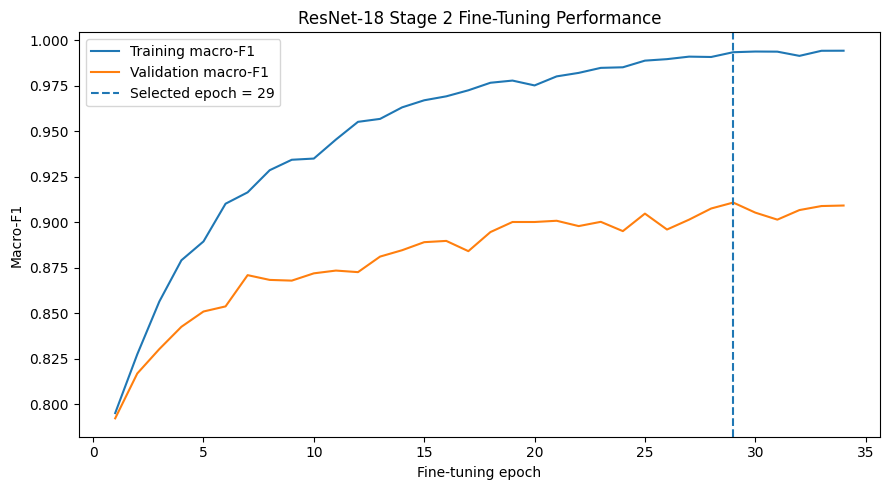

In [ ]:
# ============================================================
# 44. Final Stage 2 training-history figure
# ============================================================

stage2_history_df = pd.read_csv(
    STAGE2_HISTORY_PATH
)

best_epoch = int(
    best_stage2_checkpoint["epoch"]
)

plt.figure(figsize=(9, 5))

plt.plot(
    stage2_history_df["epoch"],
    stage2_history_df["train_macro_f1"],
    label="Training macro-F1"
)

plt.plot(
    stage2_history_df["epoch"],
    stage2_history_df["val_macro_f1"],
    label="Validation macro-F1"
)

plt.axvline(
    best_epoch,
    linestyle="--",
    label=f"Selected epoch = {best_epoch}"
)

plt.xlabel("Fine-tuning epoch")
plt.ylabel("Macro-F1")
plt.title(
    "ResNet-18 Stage 2 Fine-Tuning Performance"
)

plt.legend()
plt.tight_layout()

plt.savefig(
    RESULTS_DIR
    / "resnet18_stage2_macro_f1_history.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

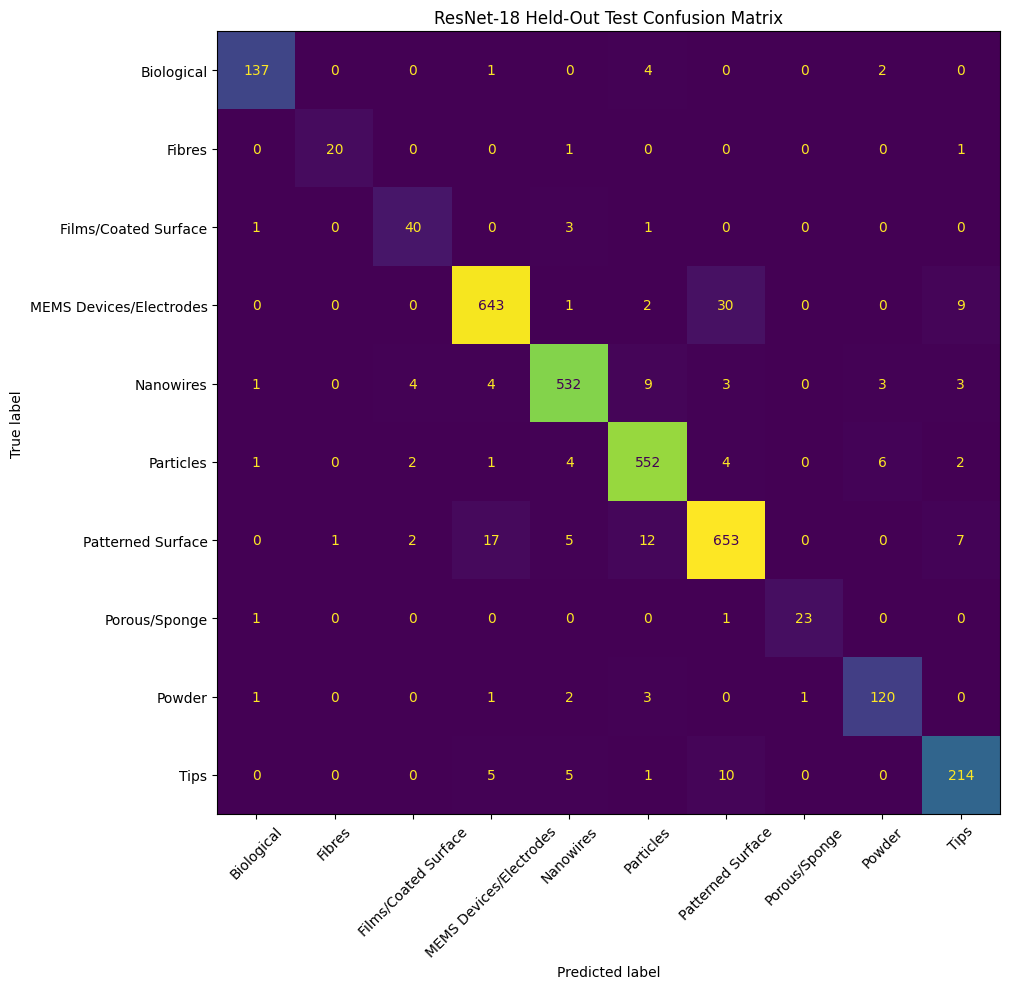

In [ ]:
# ============================================================
# 45. Final held-out test confusion matrix
# ============================================================

from sklearn.metrics import ConfusionMatrixDisplay

fig, ax = plt.subplots(
    figsize=(11, 10)
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=test_confusion_matrix,
    display_labels=classes
)

disp.plot(
    ax=ax,
    xticks_rotation=45,
    values_format="d",
    colorbar=False
)

ax.set_title(
    "ResNet-18 Held-Out Test Confusion Matrix"
)

plt.tight_layout()

plt.savefig(
    RESULTS_DIR
    / "resnet18_test_confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [ ]:
# ============================================================
# 46. Save final reusable model package
# ============================================================

FINAL_MODEL_PATH = (
    MODEL_DIR
    / "resnet18_sem_final.pt"
)

final_model_package = {
    "architecture": "resnet18",

    "model_state_dict":
        model.state_dict(),

    "class_to_idx":
        class_to_idx,

    "idx_to_class":
        idx_to_class,

    "selected_stage":
        2,

    "selected_epoch":
        int(best_stage2_checkpoint["epoch"]),

    "crop_fraction":
        CROP_FRACTION,

    "image_size":
        IMAGE_SIZE,

    "imagenet_mean":
        IMAGENET_MEAN,

    "imagenet_std":
        IMAGENET_STD,

    "test_accuracy":
        float(test_accuracy),

    "test_balanced_accuracy":
        float(test_balanced_accuracy),

    "test_macro_f1":
        float(test_macro_f1),

    "seed":
        SEED
}

torch.save(
    final_model_package,
    FINAL_MODEL_PATH
)

print(
    "Final model saved to:",
    FINAL_MODEL_PATH
)

Final model saved to: /content/drive/MyDrive/intelligent-microscopy-materials/models/transfer_learning/resnet18_sem_final.pt


In [ ]:
# ============================================================
# 47. Final experiment summary
# ============================================================

experiment_summary = pd.DataFrame({
    "property": [
        "architecture",
        "pretraining",
        "input_channels",
        "image_height",
        "image_width",
        "selected_stage",
        "selected_epoch",
        "validation_macro_f1",
        "test_accuracy",
        "test_balanced_accuracy",
        "test_macro_f1"
    ],

    "value": [
        "ResNet-18",
        "ImageNet",
        3,
        IMAGE_SIZE[0],
        IMAGE_SIZE[1],
        2,
        int(best_stage2_checkpoint["epoch"]),
        best_stage2_checkpoint[
            "val_macro_f1"
        ],
        test_accuracy,
        test_balanced_accuracy,
        test_macro_f1
    ]
})

display(experiment_summary)

experiment_summary.to_csv(
    RESULTS_DIR
    / "resnet18_experiment_summary.csv",
    index=False
)

,property,value
0,architecture,ResNet-18
1,pretraining,ImageNet
2,input_channels,3
3,image_height,150
4,image_width,256
5,selected_stage,2
6,selected_epoch,29
7,validation_macro_f1,0.910756
8,test_accuracy,0.942802
9,test_balanced_accuracy,0.93098


## 15. Conclusion

Transfer learning substantially improved SEM morphology classification over
both the classical handcrafted-feature baseline and the convolutional neural
network trained from scratch.

The final model used an ImageNet-pretrained ResNet-18. In Stage 1, the
pretrained feature extractor was frozen while a new ten-class classification
head was trained. In Stage 2, the highest-level residual block (`layer4`) and
the classification head were fine-tuned using lower learning rates to permit
controlled adaptation to SEM morphology.

Model development and checkpoint selection were performed using the training
and validation partitions only. The final Stage 2 model was selected at epoch
29 based on validation macro-F1.

The selected model achieved:

- validation macro-F1: 0.9108
- held-out test accuracy: 0.9428
- held-out test balanced accuracy: 0.9310
- held-out test macro-F1: 0.9316

This substantially exceeded the HistGradientBoosting baseline and the CNN
trained from scratch, demonstrating the value of pretrained visual
representations combined with controlled domain-specific fine-tuning.

Performance remained strong across both majority and minority morphology
classes. Residual classification errors were concentrated among morphologically
related categories, including MEMS Devices/Electrodes and Patterned Surface.

Artifact-stratified evaluation showed similar overall accuracy between
overlay-positive and overlay-negative images. The large Patterned Surface
overlay-performance difference observed in the scratch CNN was substantially
reduced in the transfer-learning model, although a smaller difference remained.

These observations do not establish whether image annotations or acquisition
features influence individual predictions. Notebook 05 therefore investigates
model decision-making using explainability, uncertainty, calibration, failure
analysis, and targeted artifact perturbation experiments.

No further model selection is performed using the held-out test set.